## Installation of scikit-learn

In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sklearn
print(sklearn.__version__)

1.9.0


## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 5)

## Installation of liabraries

In [4]:
pip install statsmodels prophet scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Data Loading

In [5]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\SATYA\OneDrive\Desktop\Week3-Work-Demand-Forecasting
['.idea', '.ipynb_checkpoints', 'demand_forecasting.ipynb', 'final_anomaly_dataset.csv', 'final_anomaly_results.csv']


## Building and debugging a forecasting pipeline

In [6]:
import pandas as pd

df = pd.read_csv(
    "final_anomaly_results.csv",
    parse_dates=["OrderDate"]
)

df = df.sort_values(
    ["CategoryName", "OrderDate"]
).reset_index(drop=True)

df.head()

,OrderDate,CategoryName,Quantity,ZScore,ZScore_Anomaly,IQR_Lower,IQR_Upper,IQR_Anomaly,IF_Anomaly,Anomaly_Method_Count,Final_Anomaly
0,2013-06-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
1,2013-07-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
2,2013-08-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
3,2013-09-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False
4,2013-10-01,CPU,0.0,-0.583121,False,-228.75,381.25,False,False,0,False


<Axes: title={'center': 'CPU Monthly Demand'}, xlabel='OrderDate'>

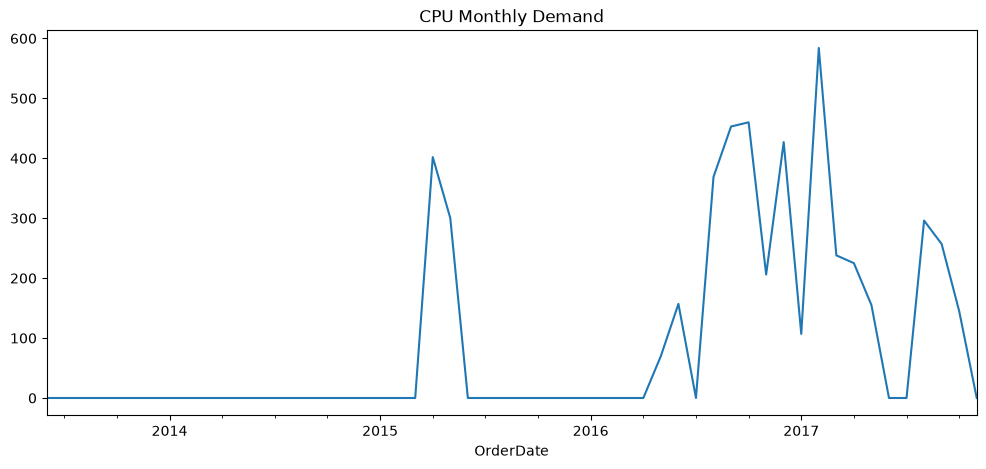

In [7]:
category = "CPU"
series = df[df["CategoryName"] == category].set_index("OrderDate")["Quantity"]
series = series.asfreq("MS")  # MS = Month Start, ensures a continuous monthly index
series.plot(title=f"{category} Monthly Demand")

In [8]:
print("Missing months after asfreq:", series.isna().sum())
series = series.ffill()  # only if any exist

Missing months after asfreq: 0


## Chronological train/test split

In [9]:
test_months = 6  # hold out the last 6 months as "unseen" test data
train = series.iloc[:-test_months]
test = series.iloc[-test_months:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} months)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} months)")

Train: 2013-06-01 00:00:00 to 2017-05-01 00:00:00 (48 months)
Test:  2017-06-01 00:00:00 to 2017-11-01 00:00:00 (6 months)


## Simple Moving Average

In [10]:
def moving_average_forecast(train, test, window=3):
    history = list(train)
    preds = []
    for _ in range(len(test)):
        forecast = np.mean(history[-window:])
        preds.append(forecast)
        history.append(forecast)  # roll forward using our own prediction
    return pd.Series(preds, index=test.index)

ma_preds = moving_average_forecast(train, test, window=3)

ma_mape = mean_absolute_percentage_error(test, ma_preds) * 100
ma_rmse = np.sqrt(mean_squared_error(test, ma_preds))
print(f"Moving Average — MAPE: {ma_mape:.1f}%  RMSE: {ma_rmse:.1f}")

Moving Average — MAPE: 44464551876542038016.0%  RMSE: 150.2


## ARIMA / SARIMA model

In [11]:
def moving_average_forecast(train, test, window=3):
    history = list(train)
    preds = []
    for _ in range(len(test)):
        forecast = np.mean(history[-window:])
        preds.append(forecast)
        history.append(forecast)  # roll forward using our own prediction
    return pd.Series(preds, index=test.index)

ma_preds = moving_average_forecast(train, test, window=3)

ma_mape = mean_absolute_percentage_error(test, ma_preds) * 100
ma_rmse = np.sqrt(mean_squared_error(test, ma_preds))
print(f"Moving Average — MAPE: {ma_mape:.1f}%  RMSE: {ma_rmse:.1f}")

Moving Average — MAPE: 44464551876542038016.0%  RMSE: 150.2


In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# order=(p,d,q) non-seasonal, seasonal_order=(P,D,Q,s) seasonal with s=12 (monthly cycle)
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fitted = model.fit(disp=False)
print(fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           Quantity   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -138.517
Date:                            Mon, 27 Jul 2026   AIC                            287.034
Time:                                    19:01:11   BIC                            292.257
Sample:                                06-01-2013   HQIC                           288.168
                                     - 05-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5544      0.399     -1.389      0.165      -1.337       0.228
ma.L1          0.0510      0.610   

In [13]:
arima_preds = fitted.forecast(steps=len(test))
arima_preds.index = test.index

arima_mape = mean_absolute_percentage_error(test, arima_preds) * 100
arima_rmse = np.sqrt(mean_squared_error(test, arima_preds))
print(f"SARIMA — MAPE: {arima_mape:.1f}%  RMSE: {arima_rmse:.1f}")

SARIMA — MAPE: 19524041124889845760.0%  RMSE: 93.9


In [14]:
import itertools

best_score, best_params = np.inf, None
p = d = q = range(0, 2)
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in itertools.product(p, d, q)]
pdq = list(itertools.product(p, d, q))

for param in pdq:
    for sparam in seasonal_pdq:
        try:
            m = SARIMAX(train, order=param, seasonal_order=sparam,
                        enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False)
            if r.aic < best_score:
                best_score, best_params = r.aic, (param, sparam)
        except Exception:
            continue

print("Best params:", best_params, "AIC:", best_score)

Best params: ((0, 1, 1), (0, 1, 1, 12)) AIC: 284.0568476202313


In [17]:
from prophet import Prophet

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_train)

future = m.make_future_dataframe(periods=len(test), freq="MS")
forecast = m.predict(future)

prophet_preds = forecast.set_index("ds")["yhat"].iloc[-len(test):]
prophet_preds.index = test.index  # align index for comparison

prophet_mape = mean_absolute_percentage_error(test, prophet_preds) * 100
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_preds))
print(f"Prophet — MAPE: {prophet_mape:.1f}%  RMSE: {prophet_rmse:.1f}")

19:02:00 - cmdstanpy - INFO - Chain [1] start processing
19:02:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAPE: 52598862447590735872.0%  RMSE: 185.4


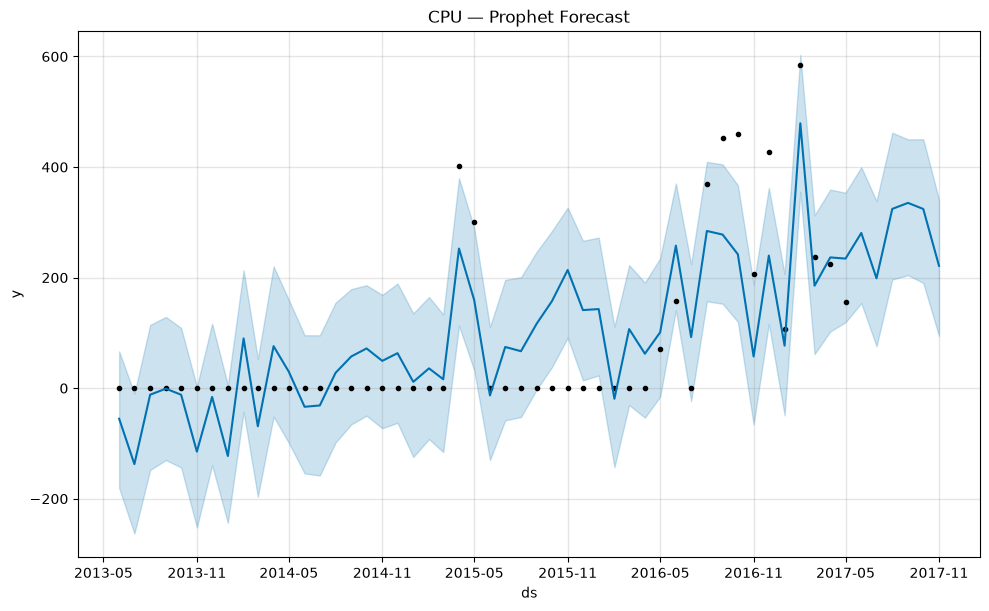

In [18]:
m.plot(forecast)
plt.title(f"{category} — Prophet Forecast")
plt.show()

            Model      MAPE (%)        RMSE
0  Moving Average  4.446455e+19  150.170221
1          SARIMA  1.952404e+19   93.922294
2         Prophet  5.259886e+19  185.424974


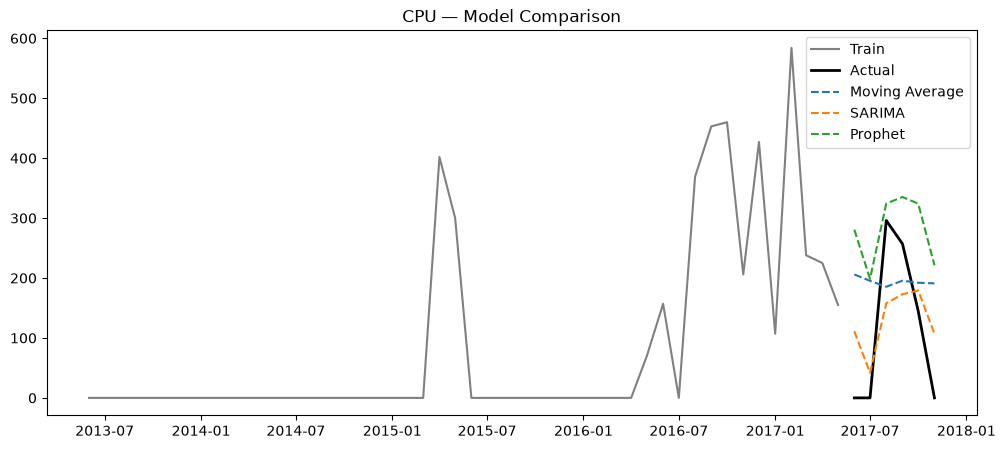

In [19]:
results = pd.DataFrame({
    "Model": ["Moving Average", "SARIMA", "Prophet"],
    "MAPE (%)": [ma_mape, arima_mape, prophet_mape],
    "RMSE": [ma_rmse, arima_rmse, prophet_rmse],
})
print(results)

plt.plot(train.index, train, label="Train", color="gray")
plt.plot(test.index, test, label="Actual", color="black", linewidth=2)
plt.plot(test.index, ma_preds, label="Moving Average", linestyle="--")
plt.plot(test.index, arima_preds, label="SARIMA", linestyle="--")
plt.plot(test.index, prophet_preds, label="Prophet", linestyle="--")
plt.legend()
plt.title(f"{category} — Model Comparison")
plt.show()

In [20]:
def evaluate_category(df, category, test_months=6):
    series = df[df["CategoryName"] == category].set_index("OrderDate")["Quantity"].asfreq("MS")
    train, test = series.iloc[:-test_months], series.iloc[-test_months:]

    ma_preds = moving_average_forecast(train, test, window=3)

    sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    arima_preds = sarima_model.forecast(steps=len(test))
    arima_preds.index = test.index

    p_train = train.reset_index(); p_train.columns = ["ds", "y"]
    pm = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    pm.fit(p_train)
    p_future = pm.make_future_dataframe(periods=len(test), freq="MS")
    p_forecast = pm.predict(p_future).set_index("ds")["yhat"].iloc[-len(test):]
    p_forecast.index = test.index

    def score(actual, pred):
        return (mean_absolute_percentage_error(actual, pred) * 100,
                np.sqrt(mean_squared_error(actual, pred)))

    rows = []
    for name, preds in [("Moving Average", ma_preds), ("SARIMA", arima_preds), ("Prophet", p_forecast)]:
        mape, rmse = score(test, preds)
        rows.append({"CategoryName": category, "Model": name, "MAPE": mape, "RMSE": rmse})
    return pd.DataFrame(rows)

all_results = pd.concat(
    [evaluate_category(df, cat) for cat in df["CategoryName"].unique()],
    ignore_index=True,
)
all_results

19:02:30 - cmdstanpy - INFO - Chain [1] start processing
19:02:31 - cmdstanpy - INFO - Chain [1] done processing
19:02:31 - cmdstanpy - INFO - Chain [1] start processing
19:02:31 - cmdstanpy - INFO - Chain [1] done processing
19:02:32 - cmdstanpy - INFO - Chain [1] start processing
19:02:32 - cmdstanpy - INFO - Chain [1] done processing
19:02:33 - cmdstanpy - INFO - Chain [1] start processing
19:02:33 - cmdstanpy - INFO - Chain [1] done processing
19:02:34 - cmdstanpy - INFO - Chain [1] start processing
19:02:34 - cmdstanpy - INFO - Chain [1] done processing


,CategoryName,Model,MAPE,RMSE
0,CPU,Moving Average,4.446455e+19,150.170221
1,CPU,SARIMA,1.952404e+19,93.922294
2,CPU,Prophet,5.259886e+19,185.424974
3,Mother Board,Moving Average,6.666667e+01,127.432335
4,Mother Board,SARIMA,2.640122e+19,136.380273
5,Mother Board,Prophet,2.745018e+19,162.490004
6,RAM,Moving Average,9.369629e+18,34.863232
7,RAM,SARIMA,4.093917e+19,145.561741
8,RAM,Prophet,3.596127e+19,95.679550
9,Storage,Moving Average,2.727396e+19,97.778041


In [21]:
# Which model wins per category?
best_model_per_category = all_results.loc[all_results.groupby("CategoryName")["RMSE"].idxmin()]
best_model_per_category

,CategoryName,Model,MAPE,RMSE
1,CPU,SARIMA,1.952404e+19,93.922294
3,Mother Board,Moving Average,6.666667e+01,127.432335
6,RAM,Moving Average,9.369629e+18,34.863232
9,Storage,Moving Average,2.727396e+19,97.778041
12,Video Card,Moving Average,3.487788e+19,121.350128


In [22]:
all_results.to_csv("model_comparison_results.csv", index=False)
best_model_per_category.to_csv("best_model_per_category.csv", index=False)

In [23]:
future_horizon = 3  # ~90 days, since data is monthly

final_forecasts = []
for cat in df["CategoryName"].unique():
    series = df[df["CategoryName"] == cat].set_index("OrderDate")["Quantity"].asfreq("MS")

    # Example: using SARIMA as the winner — swap in whichever model actually won for this category
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    forecast = model.get_forecast(steps=future_horizon)
    mean_fc = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.20)  # 80% confidence interval

    result = pd.DataFrame({
        "OrderDate": mean_fc.index,
        "CategoryName": cat,
        "Forecast": mean_fc.values,
        "Lower_CI": conf_int.iloc[:, 0].values,
        "Upper_CI": conf_int.iloc[:, 1].values,
    })
    final_forecasts.append(result)

future_df = pd.concat(final_forecasts, ignore_index=True)
future_df.to_csv("future_demand_forecast.csv", index=False)
future_df

,OrderDate,CategoryName,Forecast,Lower_CI,Upper_CI
0,2017-12-01,CPU,130.274345,-7.875907e+01,3.393078e+02
1,2018-01-01,CPU,-68.883790,-3.089316e+02,1.711640e+02
2,2018-02-01,CPU,233.604243,-5.736820e+01,5.245767e+02
3,2017-12-01,Mother Board,-2246.192406,-1.793559e+10,1.793558e+10
4,2018-01-01,Mother Board,-4012.074490,-2.027310e+10,2.027309e+10
5,2018-02-01,Mother Board,-5244.068584,-2.058885e+10,2.058884e+10
6,2017-12-01,RAM,13.050218,-1.518389e+09,1.518389e+09
7,2018-01-01,RAM,-240.417318,-1.865764e+09,1.865763e+09
8,2018-02-01,RAM,-584.652669,-2.045340e+09,2.045339e+09
9,2017-12-01,Storage,97.103580,-1.574064e+02,3.516136e+02


In [25]:
anomaly_counts = pd.read_csv("final_anomaly_dataset.csv")

print(anomaly_counts.columns.tolist())

['OrderDate', 'CategoryName', 'Quantity', 'ZScore', 'ZScore_Anomaly', 'IQR_Lower', 'IQR_Upper', 'IQR_Anomaly', 'IF_Anomaly', 'Anomaly_Method_Count', 'Final_Anomaly']


In [26]:
anomaly_counts.columns = anomaly_counts.columns.str.strip()

print(anomaly_counts.columns)

Index(['OrderDate', 'CategoryName', 'Quantity', 'ZScore', 'ZScore_Anomaly',
       'IQR_Lower', 'IQR_Upper', 'IQR_Anomaly', 'IF_Anomaly',
       'Anomaly_Method_Count', 'Final_Anomaly'],
      dtype='str')


In [29]:
anomaly_counts = pd.read_csv("final_anomaly_dataset.csv")

print(anomaly_counts.columns.tolist())
print(anomaly_counts.head())

['OrderDate', 'CategoryName', 'Quantity', 'ZScore', 'ZScore_Anomaly', 'IQR_Lower', 'IQR_Upper', 'IQR_Anomaly', 'IF_Anomaly', 'Anomaly_Method_Count', 'Final_Anomaly']
    OrderDate CategoryName  Quantity    ZScore  ZScore_Anomaly  IQR_Lower  \
0  2013-06-01          CPU       0.0 -0.583121           False    -228.75   
1  2013-07-01          CPU       0.0 -0.583121           False    -228.75   
2  2013-08-01          CPU       0.0 -0.583121           False    -228.75   
3  2013-09-01          CPU       0.0 -0.583121           False    -228.75   
4  2013-10-01          CPU       0.0 -0.583121           False    -228.75   

   IQR_Upper  IQR_Anomaly  IF_Anomaly  Anomaly_Method_Count  Final_Anomaly  
0     381.25        False       False                     0          False  
1     381.25        False       False                     0          False  
2     381.25        False       False                     0          False  
3     381.25        False       False                     0    

In [30]:
anomaly_counts = pd.read_csv("final_anomaly_dataset.csv")

combined = best_model_per_category.merge(
    anomaly_counts[["CategoryName", "Final_Anomaly"]],
    on="CategoryName"
)

combined.head()

,CategoryName,Model,MAPE,RMSE,Final_Anomaly
0,CPU,SARIMA,1.952404e+19,93.922294,False
1,CPU,SARIMA,1.952404e+19,93.922294,False
2,CPU,SARIMA,1.952404e+19,93.922294,False
3,CPU,SARIMA,1.952404e+19,93.922294,False
4,CPU,SARIMA,1.952404e+19,93.922294,False


In [31]:
anomaly_counts = pd.read_csv("final_anomaly_dataset.csv")

anomaly_summary = (
    anomaly_counts
    .groupby("CategoryName")["Final_Anomaly"]
    .sum()                      # True = 1, False = 0
    .reset_index(name="Final_Anomalies")
)

combined = best_model_per_category.merge(
    anomaly_summary,
    on="CategoryName",
    how="left"
)

combined.head()

,CategoryName,Model,MAPE,RMSE,Final_Anomalies
0,CPU,SARIMA,1.952404e+19,93.922294,1
1,Mother Board,Moving Average,6.666667e+01,127.432335,3
2,RAM,Moving Average,9.369629e+18,34.863232,3
3,Storage,Moving Average,2.727396e+19,97.778041,3
4,Video Card,Moving Average,3.487788e+19,121.350128,2
